# Лабораторная работа 1. Линейная регрессия и факторный анализ

| | |
|---|---|
| **Выполнил** | **Марков Данил** |
| **Группа** | **АВТ-314** |
| **Проверил** | **Антонянц Егор Николаевич** |

**Датасет:** [Car Price Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset)  
**Файл данных:** `data/cardekho.csv`  
**Целевая переменная:** `selling_price` (цена продажи автомобиля)

## 1. Введение

**Цель работы** — изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Задачи работы:**

1.Загрузить датасет из репозитория.

2.Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

3.Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

4.Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

5.Построить регрессионные модели (линейная, лассо и гребневая). Разделить на тренировочную и тестовую выборки. Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

6.Построить график остатков моделей (добавить горизонтальную линию на уровне 0) и исследовать структуру остатков на предмет гомоскедастичности или гетероскедастичности.

7.Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.

8.Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Целевая переменная — непрерывная (`selling_price`), поэтому используется регрессия, а не классификация.

## 2. Описание датасета и первичный анализ

Ниже подключаются необходимые библиотеки: `pandas`/`numpy` для работы с таблицами, `matplotlib`/`seaborn` для графиков, `scikit-learn` для моделей и PCA, `statsmodels` для расчёта VIF.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Библиотеки загружены. Зафиксирован `RANDOM_STATE = 42`, чтобы разбиение выборки и результаты кросс-валидации воспроизводились при повторном запуске ноутбука.

### 2.1. Загрузка данных

In [2]:
df_raw = pd.read_csv('data/cardekho.csv')

print(f'Размерность исходного датасета: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов')
print('\nСписок столбцов:')
print(list(df_raw.columns))
print('\nТипы данных:')
print(df_raw.dtypes)
print('\nПервые 5 строк:')
display(df_raw.head())

Размерность исходного датасета: 8128 строк, 12 столбцов

Список столбцов:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']

Типы данных:
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object

Первые 5 строк:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


Датасет содержит **8128** наблюдений и **12** признаков. Источник — площадка CarDekho (Индия).

**Кратко о признаках:**
- `name` — модель автомобиля (текстовый идентификатор);
- `year` — год выпуска;
- `selling_price` — **целевая переменная**, цена продажи;
- `km_driven` — пробег, км;
- `fuel` — тип топлива (Diesel, Petrol, CNG, LPG);
- `seller_type` — тип продавца;
- `transmission` — коробка передач (Manual / Automatic);
- `owner` — номер владельца;
- `mileage(km/ltr/kg)` — расход/пробег на единицу топлива;
- `engine` — объём двигателя, см³;
- `max_power` — максимальная мощность (в файле хранится как текст);
- `seats` — число посадочных мест.

Далее выполняется первичный анализ пропусков и описательных статистик.

### 2.2. Пропуски, дубликаты и описательная статистика

In [3]:
print('Пропущенные значения по столбцам:')
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Доля, %': missing_pct})
display(missing_df[missing_df['Пропуски'] > 0])

dup_count = df_raw.duplicated().sum()
print(f'\nЧисло полных дубликатов: {dup_count}')

print('\nОписательная статистика числовых столбцов:')
display(df_raw.describe().T.round(2))

print('\nРаспределение категориальных признаков:')
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    counts = df_raw[col].value_counts()
    pct = (df_raw[col].value_counts(normalize=True) * 100).round(2)
    print(f'\n{col}:')
    display(pd.DataFrame({'Количество': counts, 'Доля, %': pct}))

Пропущенные значения по столбцам:


,Пропуски,"Доля, %"
mileage(km/ltr/kg),221,2.72
engine,221,2.72
max_power,215,2.65
seats,221,2.72



Число полных дубликатов: 1202

Описательная статистика числовых столбцов:


,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.80,4.04,1983.0,2011.00,2015.0,2017.00,2020.0
selling_price,8128.0,638271.81,806253.40,29999.0,254999.00,450000.0,675000.00,10000000.0
km_driven,8128.0,69819.51,56550.55,1.0,35000.00,60000.0,98000.00,2360457.0
mileage(km/ltr/kg),7907.0,19.42,4.04,0.0,16.78,19.3,22.32,42.0
engine,7907.0,1458.63,503.92,624.0,1197.00,1248.0,1582.00,3604.0
seats,7907.0,5.42,0.96,2.0,5.00,5.0,5.00,14.0



Распределение категориальных признаков:

fuel:


...

,Количество,"Доля, %"
seller_type,,
Individual,6766,83.24
Dealer,1126,13.85
Trustmark Dealer,236,2.90



transmission:


,Количество,"Доля, %"
transmission,,
Manual,7078,87.08
Automatic,1050,12.92



owner:


,Количество,"Доля, %"
owner,,
First Owner,5289,65.07
Second Owner,2105,25.90
Third Owner,555,6.83
Fourth & Above Owner,174,2.14
Test Drive Car,5,0.06


**Выводы по первичному анализу:**
- Пропуски сосредоточены в `mileage`, `engine`, `max_power`, `seats` (около 2–3% строк). Их доля невелика, поэтому в предобработке такие строки будут удалены.
- Есть полные дубликаты — их тоже удалим, чтобы не искажать обучение.
- Цена продажи сильно варьируется (от десятков тысяч до миллионов) — распределение, скорее всего, асимметричное.
- Среди продавцов преобладают частные лица (`Individual`), среди коробок передач — механика (`Manual`).

### 2.3. Визуализация распределений признаков и целевой переменной

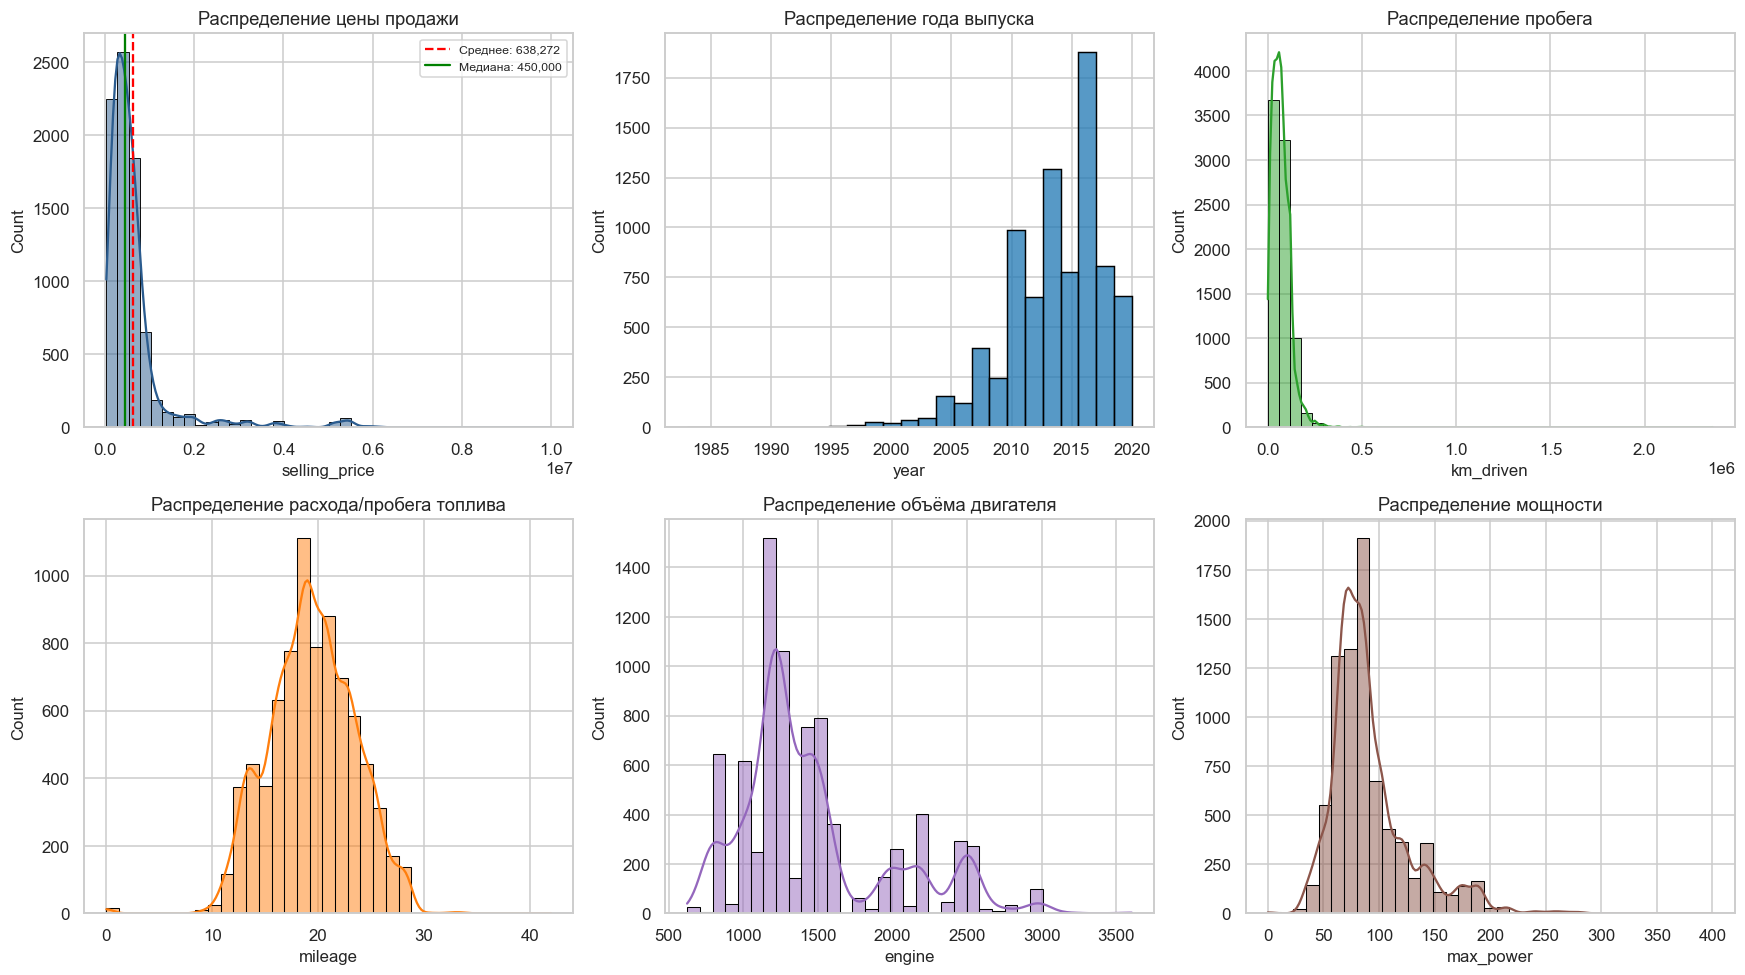

In [4]:
df_viz = df_raw.copy()
df_viz['max_power_num'] = pd.to_numeric(df_viz['max_power'], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df_viz['selling_price'], bins=40, kde=True, ax=axes[0, 0], color='#2b5c8f', edgecolor='black')
axes[0, 0].axvline(df_viz['selling_price'].mean(), color='red', ls='--', label=f"Среднее: {df_viz['selling_price'].mean():,.0f}")
axes[0, 0].axvline(df_viz['selling_price'].median(), color='green', ls='-', label=f"Медиана: {df_viz['selling_price'].median():,.0f}")
axes[0, 0].set_title('Распределение цены продажи')
axes[0, 0].set_xlabel('selling_price')
axes[0, 0].legend(fontsize=8)

sns.histplot(df_viz['year'], bins=25, kde=False, ax=axes[0, 1], color='#1f77b4', edgecolor='black')
axes[0, 1].set_title('Распределение года выпуска')
axes[0, 1].set_xlabel('year')

sns.histplot(df_viz['km_driven'], bins=40, kde=True, ax=axes[0, 2], color='#2ca02c', edgecolor='black')
axes[0, 2].set_title('Распределение пробега')
axes[0, 2].set_xlabel('km_driven')

sns.histplot(df_viz['mileage(km/ltr/kg)'].dropna(), bins=35, kde=True, ax=axes[1, 0], color='#ff7f0e', edgecolor='black')
axes[1, 0].set_title('Распределение расхода/пробега топлива')
axes[1, 0].set_xlabel('mileage')

sns.histplot(df_viz['engine'].dropna(), bins=35, kde=True, ax=axes[1, 1], color='#9467bd', edgecolor='black')
axes[1, 1].set_title('Распределение объёма двигателя')
axes[1, 1].set_xlabel('engine')

sns.histplot(df_viz['max_power_num'].dropna(), bins=35, kde=True, ax=axes[1, 2], color='#8c564b', edgecolor='black')
axes[1, 2].set_title('Распределение мощности')
axes[1, 2].set_xlabel('max_power')

plt.tight_layout()
plt.show()

Графики показывают, что цена продажи и пробег имеют **правостороннюю асимметрию**: большинство автомобилей в среднем ценовом сегменте, но есть дорогие выбросы. Год выпуска смещён к более новым машинам (2010–2020). Объём двигателя и мощность также асимметричны — это типично для рынка подержанных авто.

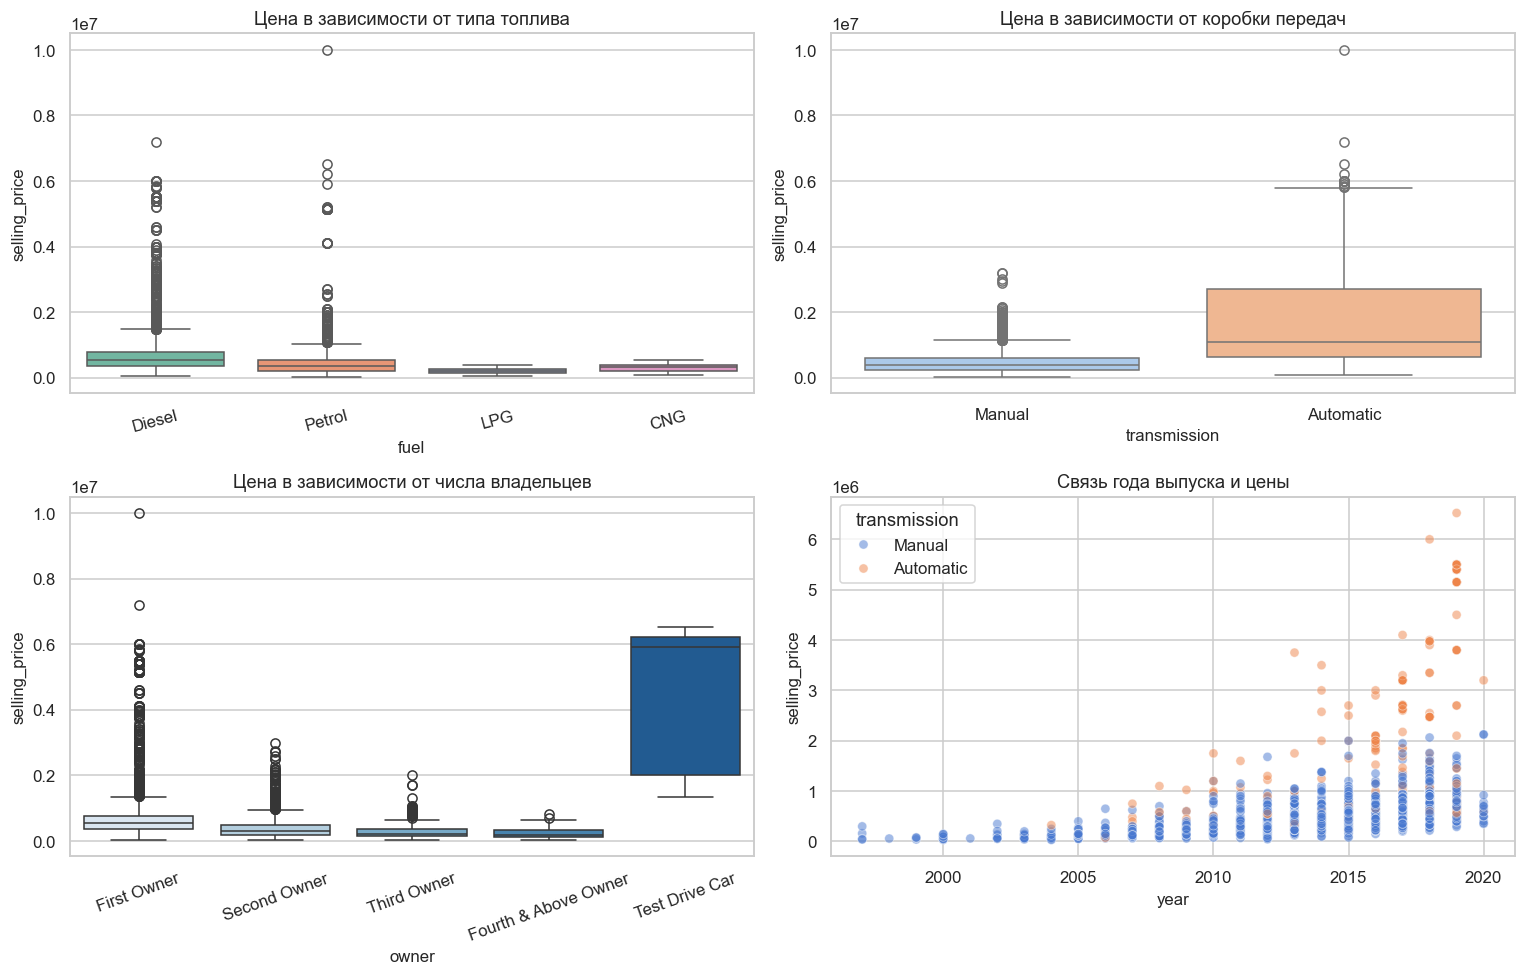

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=df_viz, x='fuel', y='selling_price', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Цена в зависимости от типа топлива')
axes[0, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df_viz, x='transmission', y='selling_price', ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Цена в зависимости от коробки передач')

sns.boxplot(data=df_viz, x='owner', y='selling_price', ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Цена в зависимости от числа владельцев')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.scatterplot(data=df_viz.sample(n=min(2000, len(df_viz)), random_state=RANDOM_STATE),
                x='year', y='selling_price', hue='transmission', alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Связь года выпуска и цены')

plt.tight_layout()
plt.show()

Видно, что **автоматическая коробка** обычно дороже механики, а более новые автомобили стоят существенно выше. Число предыдущих владельцев также влияет на цену: у первого владельца медианная цена выше. Эти зависимости подтверждают целесообразность включения категориальных признаков в регрессионные модели.

## 3. Подготовка данных

### 3.1. Очистка, преобразование типов и кодирование

In [6]:
df = df_raw.copy()

df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

df['brand'] = df['name'].astype(str).str.split().str[0]
top_brands = df['brand'].value_counts().nlargest(10).index
df['brand'] = df['brand'].where(df['brand'].isin(top_brands), 'Other')

max_year = int(df['year'].max())
df['car_age'] = max_year - df['year']

df = df.drop(columns=['name', 'year'])

df = df[df['owner'] != 'Test Drive Car'].copy()

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Удалено дубликатов: {before - len(df)}')

before_na = len(df)
df = df.dropna().reset_index(drop=True)
print(f'Удалено строк с пропусками: {before_na - len(df)}')
print(f'Итоговый размер после очистки: {df.shape}')

df = df.rename(columns={'mileage(km/ltr/kg)': 'mileage'})

print('\nПервые строки после очистки:')
display(df.head())

Удалено дубликатов: 1221
Удалено строк с пропусками: 209
Итоговый размер после очистки: (6693, 12)

Первые строки после очистки:


,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,Maruti,6
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,Other,6
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,Honda,14
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,Hyundai,10
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,Maruti,13


**Что сделано на этом шаге:**
1. `max_power` преобразован в числовой тип (`pd.to_numeric`).
2. Из `name` извлечён бренд; оставлены 10 самых частых, остальные — `Other` (снижает размерность one-hot кодирования).
3. Вместо года выпуска введён `car_age` — возраст авто.
4. Удалены дубликаты, пропуски и редкий класс `Test Drive Car`.
5. Столбец `name` убран: это почти уникальный идентификатор, а не устойчивый признак для линейной модели.

In [7]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(f'Размерность после One-Hot Encoding: {df_encoded.shape}')
print('Список признаков:')
print(list(df_encoded.columns))
display(df_encoded.head())

Размерность после One-Hot Encoding: (6693, 26)
Список признаков:
['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Third Owner', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti', 'brand_Other', 'brand_Renault', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']


,selling_price,km_driven,mileage,engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,...,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Other,brand_Renault,brand_Tata,brand_Toyota,brand_Volkswagen
0,450000,145500,23.40,1248.0,74.00,5.0,6,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1,370000,120000,21.14,1498.0,103.52,5.0,6,1,0,0,...,0,0,0,0,0,1,0,0,0,0
2,158000,140000,17.70,1497.0,78.00,5.0,14,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,225000,127000,23.00,1396.0,90.00,5.0,10,1,0,0,...,0,0,1,0,0,0,0,0,0,0
4,130000,120000,16.10,1298.0,88.20,5.0,13,0,0,1,...,0,0,0,0,1,0,0,0,0,0


Категориальные признаки закодированы методом **One-Hot Encoding** с параметром `drop_first=True`. Это создаёт бинарные столбцы и убирает одну категорию-эталон, чтобы не вводить идеальную мультиколлинеарность между дамми-переменными. Целевая переменная `selling_price` остаётся числовой.

### 3.2. Матрица корреляций и анализ связи с целевой переменной

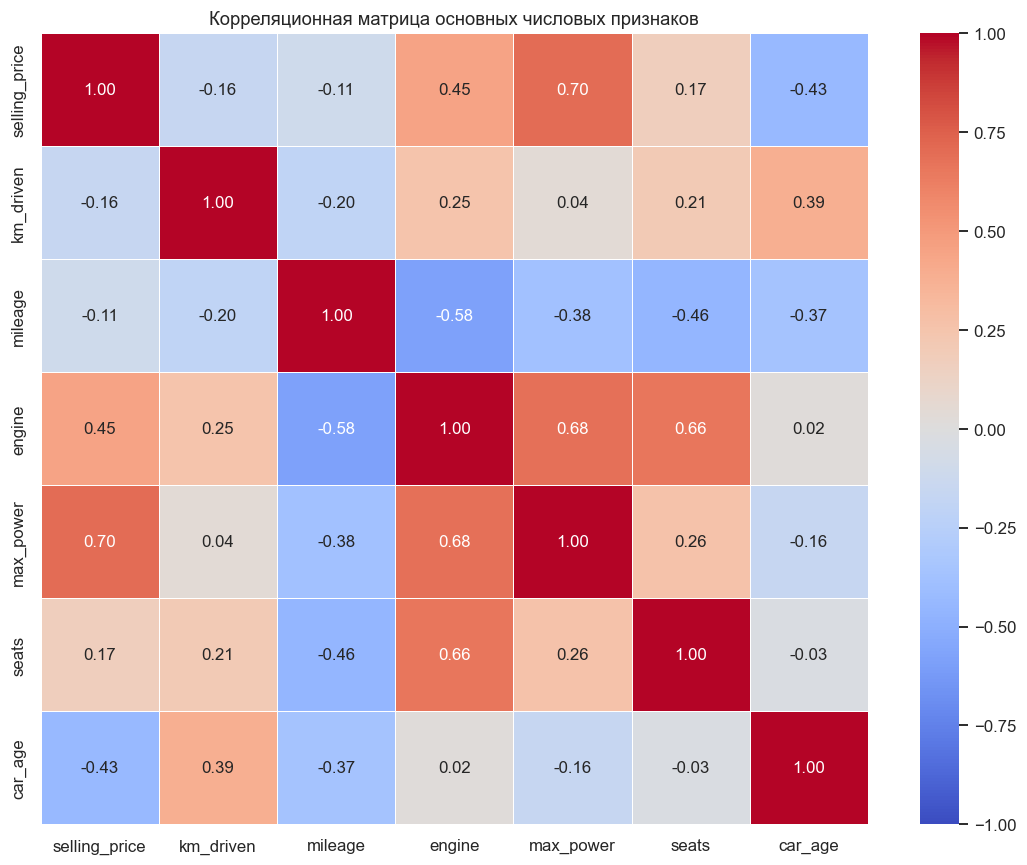

Корреляция признаков с selling_price (по модулю, топ-15):


,corr_with_target
max_power,0.697
transmission_Manual,-0.463
engine,0.451
car_age,-0.432
brand_Other,0.366
fuel_Diesel,0.267
fuel_Petrol,-0.255
seller_type_Individual,-0.252
brand_Toyota,0.188
brand_Maruti,-0.171


In [8]:
num_for_corr = ['selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']
corr_full = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_full.loc[num_for_corr, num_for_corr], annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляционная матрица основных числовых признаков')
plt.tight_layout()
plt.show()

target_corr = corr_full['selling_price'].drop('selling_price').sort_values(key=abs, ascending=False)
print('Корреляция признаков с selling_price (по модулю, топ-15):')
display(target_corr.head(15).to_frame('corr_with_target').round(3))

**Интерпретация корреляций:**
- С ценой сильнее всего связаны мощность (`max_power`), объём двигателя (`engine`), возраст (`car_age`, обычно отрицательная связь) и тип трансмиссии.
- Между `engine` и `max_power` ожидается высокая положительная корреляция — это первый сигнал возможной **мультиколлинеарности**.
- `mileage` и `car_age`/`km_driven` также могут быть связаны между собой.

Для формальной проверки мультиколлинеарности далее рассчитывается VIF.

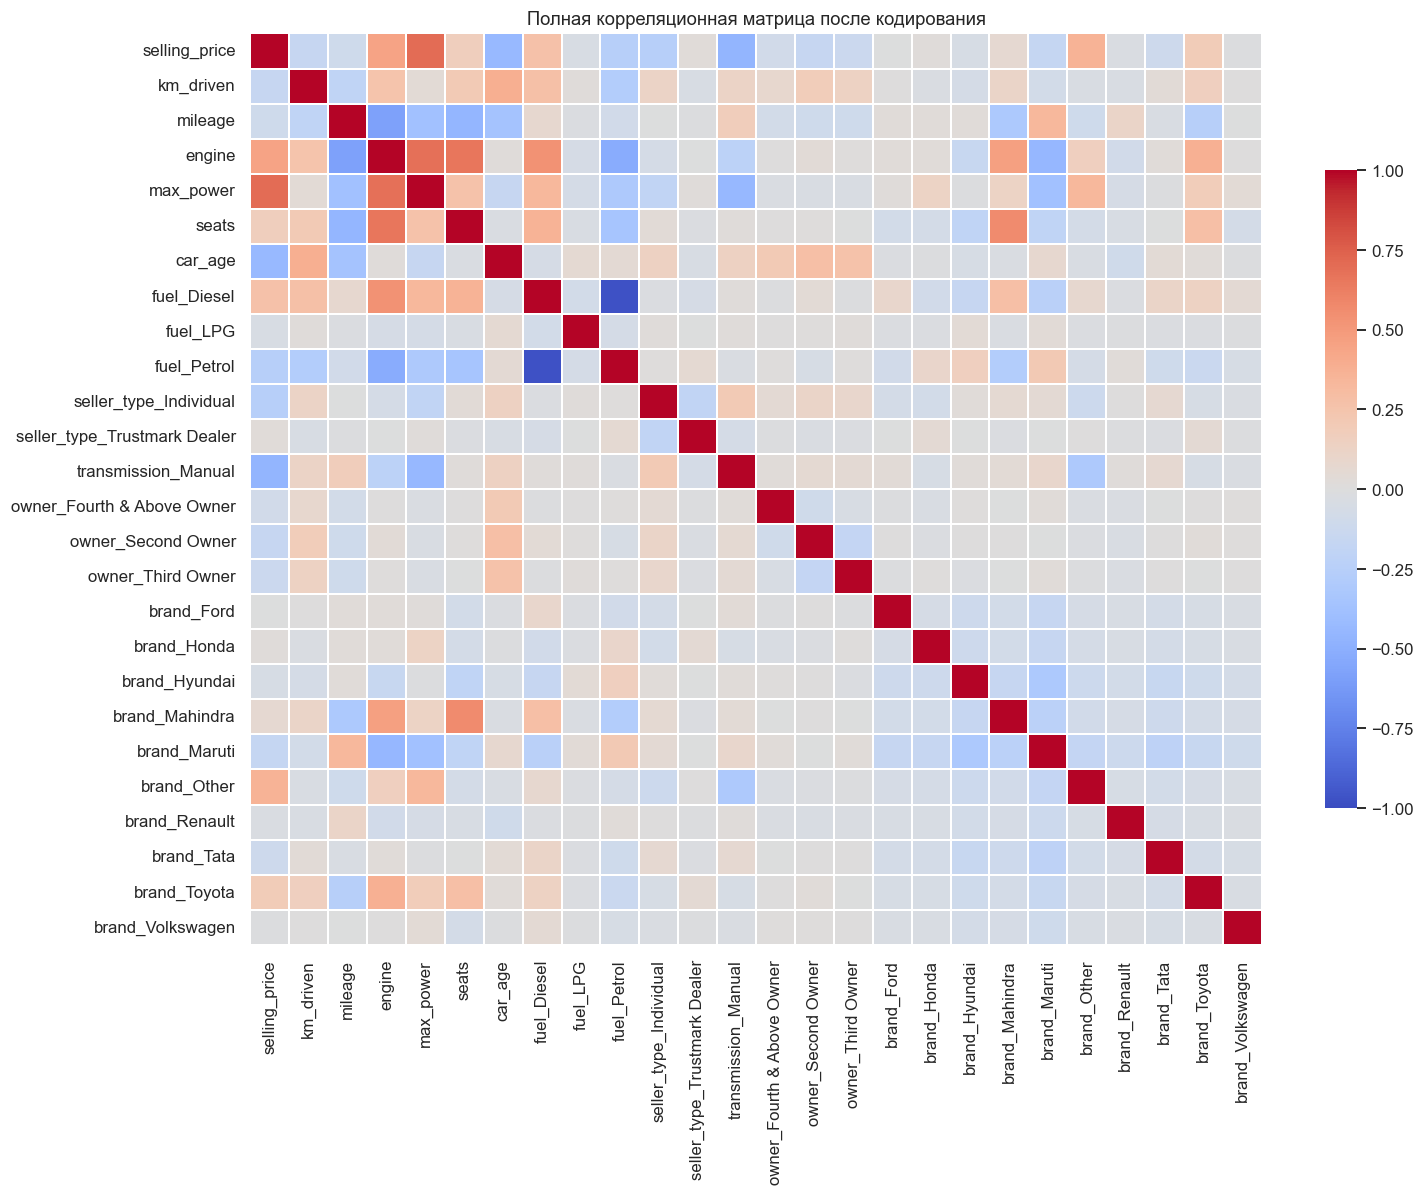

In [9]:
plt.figure(figsize=(14, 11))
sns.heatmap(corr_full, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.2, cbar_kws={'shrink': 0.7})
plt.title('Полная корреляционная матрица после кодирования')
plt.tight_layout()
plt.show()

Полная матрица подтверждает наличие блоков взаимосвязанных признаков (технические характеристики двигателя и часть категориальных дамми). Это обосновывает применение PCA на следующем этапе.

### 3.3. Диагностика мультиколлинеарности: VIF

Коэффициенты вздутия дисперсии (VIF):


,Признак,VIF
0,fuel_Petrol,34.188
1,fuel_Diesel,34.018
2,brand_Maruti,7.675
3,engine,6.564
4,brand_Hyundai,5.662
5,brand_Mahindra,4.429
6,brand_Tata,3.635
7,mileage,3.448
8,brand_Other,3.152
9,max_power,2.975


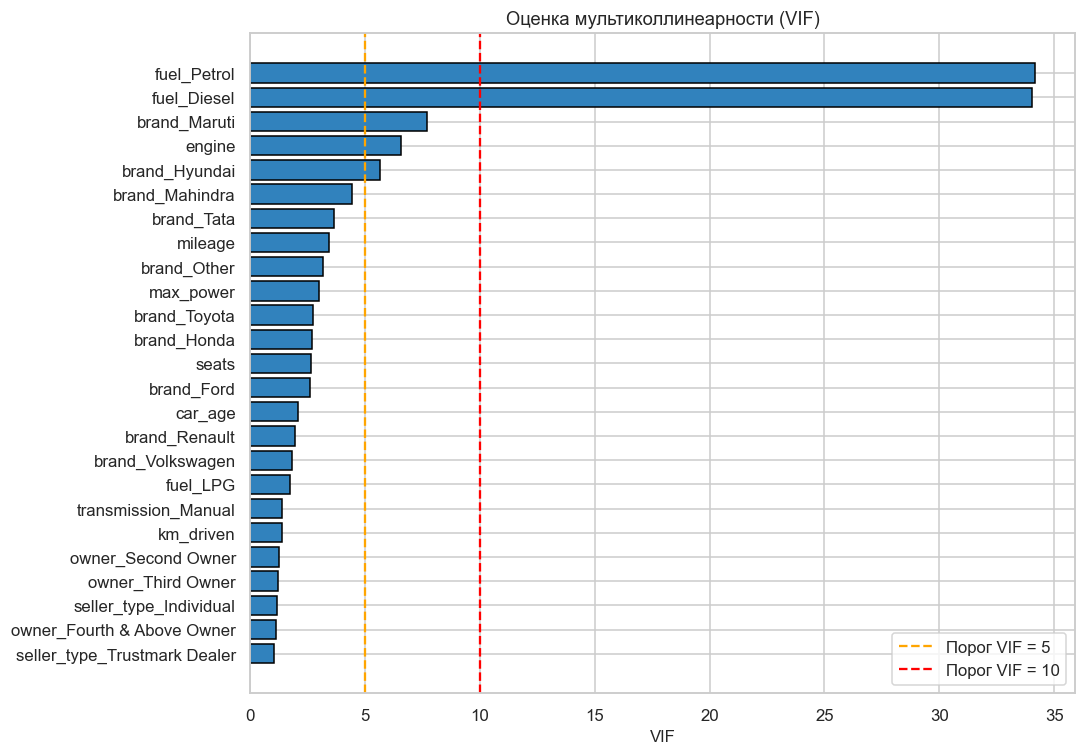

Признаков с VIF > 5: 5
Признаков с VIF > 10: 2


In [10]:
X_all = df_encoded.drop(columns=['selling_price'])
y_all = df_encoded['selling_price']

scaler_vif = StandardScaler()
X_scaled_vif = pd.DataFrame(scaler_vif.fit_transform(X_all), columns=X_all.columns)

vif_df = pd.DataFrame({
    'Признак': X_scaled_vif.columns,
    'VIF': [variance_inflation_factor(X_scaled_vif.values, i) for i in range(X_scaled_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('Коэффициенты вздутия дисперсии (VIF):')
display(vif_df.round(3))

plt.figure(figsize=(10, max(5, 0.28 * len(vif_df))))
bars = plt.barh(vif_df['Признак'], vif_df['VIF'], color='#3182bd', edgecolor='black')
plt.axvline(5, color='orange', ls='--', lw=1.5, label='Порог VIF = 5')
plt.axvline(10, color='red', ls='--', lw=1.5, label='Порог VIF = 10')
plt.xlabel('VIF')
plt.title('Оценка мультиколлинеарности (VIF)')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

print(f"Признаков с VIF > 5: {(vif_df['VIF'] > 5).sum()}")
print(f"Признаков с VIF > 10: {(vif_df['VIF'] > 10).sum()}")

**Как читать VIF:**
- VIF ≈ 1 — мультиколлинеарности почти нет;
- VIF > 5 — умеренная/заметная мультиколлинеарность;
- VIF > 10 — сильная мультиколлинеарность, оценки коэффициентов OLS нестабильны.

Если часть признаков превышает пороги 5–10, линейная модель на исходных признаках может давать неустойчивые веса. Регуляризация (Ridge/Lasso) и PCA — естественные способы смягчить эту проблему.

### 3.4. Разделение на train/test и стандартизация

In [11]:
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')
print(f'Число признаков:   {X_train.shape[1]}')
print('\nПроверка: среднее ≈ 0, стд ≈ 1 на train после стандартизации:')
display(pd.DataFrame({'mean': X_train_scaled.mean().round(4), 'std': X_train_scaled.std().round(4)}).head(8))

Обучающая выборка: 5354 объектов
Тестовая выборка:  1339 объектов
Число признаков:   25

Проверка: среднее ≈ 0, стд ≈ 1 на train после стандартизации:


,mean,std
km_driven,-0.0,1.0001
mileage,0.0,1.0001
engine,0.0,1.0001
max_power,-0.0,1.0001
seats,-0.0,1.0001
car_age,-0.0,1.0001
fuel_Diesel,0.0,1.0001
fuel_LPG,-0.0,1.0001


Выборка разделена в пропорции **80/20**. Стандартизация (`StandardScaler`) обучается **только на train**, а к test применяется тот же преобразователь — это исключает утечку данных. Стандартизация обязательна перед Ridge/Lasso и PCA, потому что эти методы чувствительны к масштабу признаков.

## 4. Ход работы

### 4.1. Регрессионные модели на исходных (стандартизированных) признаках

Обучаются три модели:
- **LinearRegression (OLS)** — обычная линейная регрессия;
- **Ridge** — L2-регуляризация, уменьшает веса коррелирующих признаков;
- **Lasso** — L1-регуляризация, может обнулять незначимые признаки.

Для каждой модели выполняется 5-fold кросс-валидация по R² на train и расчёт RMSE, R², MAPE на test.

In [12]:
def evaluate_models(models, X_tr, X_te, y_tr, y_te, space_name):
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    fitted = {}
    preds = {}

    print(f'=== Модели: {space_name} ===')
    for name, model in models.items():
        cv_r2 = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2')
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        rmse = float(np.sqrt(mean_squared_error(y_te, y_pred)))
        r2 = float(r2_score(y_te, y_pred))
        mape = float(mean_absolute_percentage_error(y_te, y_pred) * 100)

        fitted[name] = model
        preds[name] = y_pred
        rows.append({
            'Модель': name,
            'Пространство': space_name,
            'R² (CV mean)': cv_r2.mean(),
            'R² (CV std)': cv_r2.std(),
            'R² (Test)': r2,
            'RMSE (Test)': rmse,
            'MAPE (Test), %': mape
        })
        print(f"{name:<28} | R²(CV)={cv_r2.mean():.4f}±{cv_r2.std():.4f} | "
              f"R²(Test)={r2:.4f} | RMSE={rmse:,.0f} | MAPE={mape:.2f}%")

    return pd.DataFrame(rows), fitted, preds

models_orig = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=100.0, random_state=RANDOM_STATE, max_iter=10000)
}

results_orig, fitted_orig, preds_orig = evaluate_models(
    models_orig, X_train_scaled, X_test_scaled, y_train, y_test,
    space_name=f'Исходные признаки ({len(feature_names)})'
)

display(results_orig.round(4))

=== Модели: Исходные признаки (25) ===
Linear                       | R²(CV)=0.6512±0.0629 | R²(Test)=0.6893 | RMSE=265,651 | MAPE=55.08%
Ridge                        | R²(CV)=0.6513±0.0628 | R²(Test)=0.6893 | RMSE=265,656 | MAPE=54.99%
Lasso                        | R²(CV)=0.6513±0.0628 | R²(Test)=0.6892 | RMSE=265,678 | MAPE=55.05%


,Модель,Пространство,R² (CV mean),R² (CV std),R² (Test),RMSE (Test),"MAPE (Test), %"
0,Linear,Исходные признаки (25),0.6512,0.0629,0.6893,265651.1567,55.0750
1,Ridge,Исходные признаки (25),0.6513,0.0628,0.6893,265655.6308,54.9899
2,Lasso,Исходные признаки (25),0.6513,0.0628,0.6892,265678.1534,55.0548


Метрики показывают, насколько хорошо модели объясняют цену на отложенной выборке:
- **R²** — доля объяснённой дисперсии (чем ближе к 1, тем лучше);
- **RMSE** — типичная ошибка в единицах цены (чем меньше, тем лучше);
- **MAPE** — средняя относительная ошибка в процентах.

Ridge и Lasso обычно ближе к OLS, если регуляризация умеренная; при сильной мультиколлинеарности регуляризация стабилизирует решение. Ниже — визуальное сравнение метрик и график «факт vs прогноз» для линейной модели.

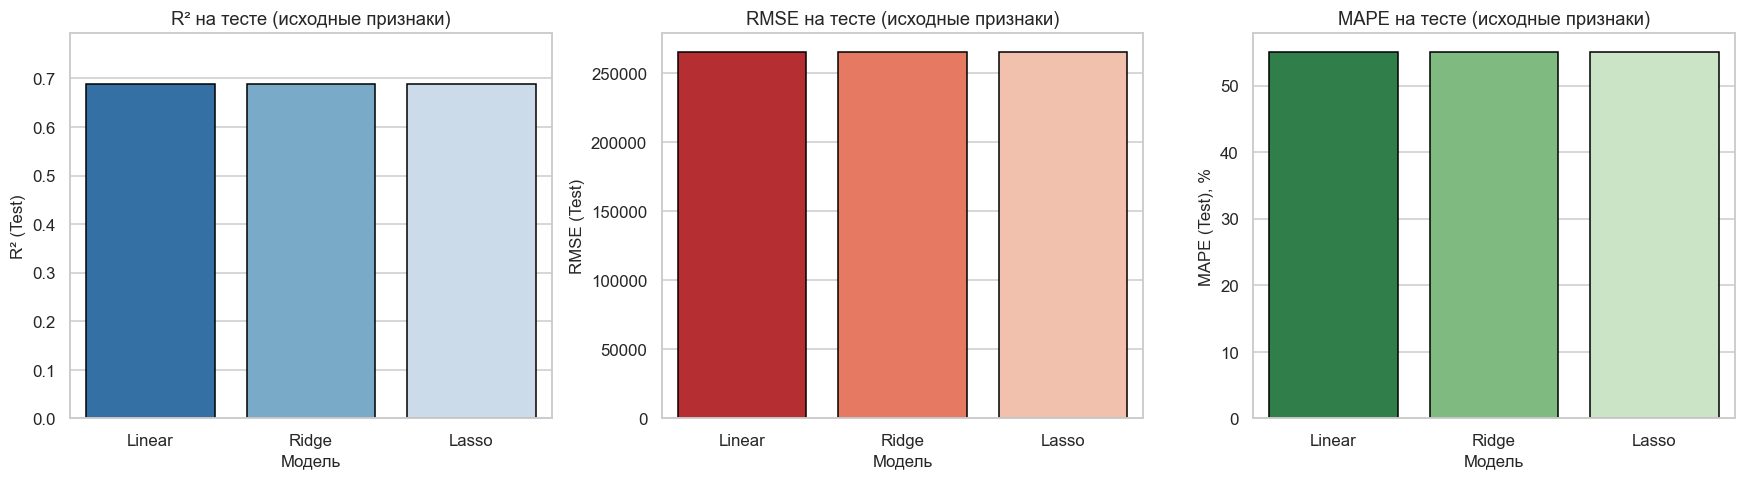

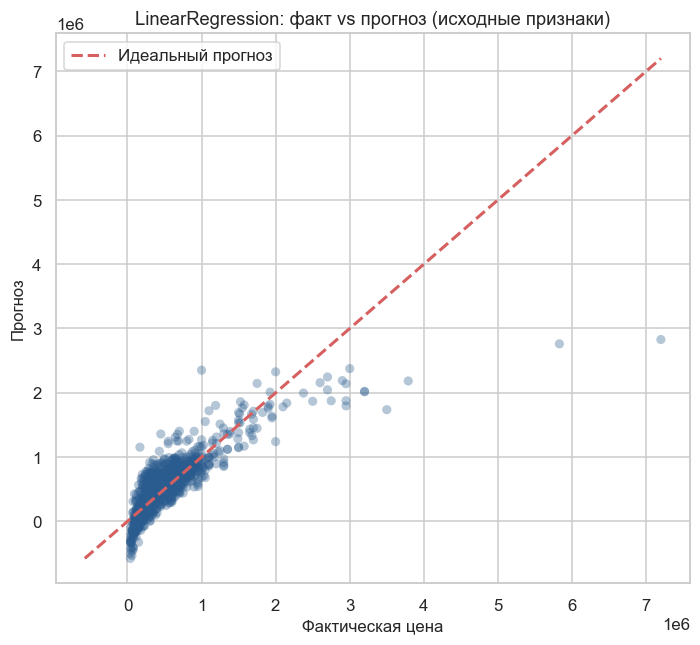

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_df = results_orig.copy()

sns.barplot(data=plot_df, x='Модель', y='R² (Test)', ax=axes[0], palette='Blues_r', edgecolor='black')
axes[0].set_title('R² на тесте (исходные признаки)')
axes[0].set_ylim(0, max(0.05, plot_df['R² (Test)'].max() * 1.15))

sns.barplot(data=plot_df, x='Модель', y='RMSE (Test)', ax=axes[1], palette='Reds_r', edgecolor='black')
axes[1].set_title('RMSE на тесте (исходные признаки)')

sns.barplot(data=plot_df, x='Модель', y='MAPE (Test), %', ax=axes[2], palette='Greens_r', edgecolor='black')
axes[2].set_title('MAPE на тесте (исходные признаки)')

plt.tight_layout()
plt.show()

y_hat = preds_orig['Linear']
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, y_hat, alpha=0.35, edgecolor='none', color='#2b5c8f')
lims = [min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Идеальный прогноз')
ax.set_xlabel('Фактическая цена')
ax.set_ylabel('Прогноз')
ax.set_title('LinearRegression: факт vs прогноз (исходные признаки)')
ax.legend()
plt.tight_layout()
plt.show()

Столбчатые диаграммы удобны для сравнения моделей «на одном экране». Диаграмма рассеяния «факт–прогноз» показывает, где модель ошибается сильнее всего: обычно это дорогие автомобили-выбросы, которые плохо описываются линейной зависимостью.

In [14]:
coef_df = pd.DataFrame({
    'Признак': feature_names,
    'Linear': fitted_orig['Linear'].coef_,
    'Ridge': fitted_orig['Ridge'].coef_,
    'Lasso': fitted_orig['Lasso'].coef_
}).sort_values('Linear', key=abs, ascending=False)

print('Топ-12 признаков по модулю коэффициента LinearRegression:')
display(coef_df.head(12).round(2))

print(f"Intercept Linear: {fitted_orig['Linear'].intercept_:,.2f}")
print(f"Число нулевых коэффициентов Lasso: {(np.abs(fitted_orig['Lasso'].coef_) < 1e-8).sum()} из {len(feature_names)}")

Топ-12 признаков по модулю коэффициента LinearRegression:


,Признак,Linear,Ridge,Lasso
3,max_power,260552.90,259538.65,260649.23
5,car_age,-143202.38,-142984.39,-143322.18
20,brand_Other,84568.10,83458.31,83517.83
19,brand_Maruti,77246.23,75004.64,75222.92
11,transmission_Manual,-66638.21,-66814.88,-66625.42
23,brand_Toyota,61049.80,59892.85,60081.36
6,fuel_Diesel,54597.11,50946.62,47957.20
0,km_driven,-37411.68,-37451.48,-37346.02
9,seller_type_Individual,-30099.19,-30170.92,-30068.10
2,engine,28302.54,29221.27,27655.55


Intercept Linear: 525,597.37
Число нулевых коэффициентов Lasso: 1 из 25


Таблица коэффициентов помогает интерпретировать модель: положительный вес увеличивает прогноз цены, отрицательный — уменьшает. У Lasso часть коэффициентов может обнулиться — это встроенный отбор признаков. При мультиколлинеарности знаки и величины коэффициентов OLS нужно трактовать осторожно.

### 4.2. Устранение мультиколлинеарности методом главных компонент (PCA)

Перед PCA данные уже стандартизированы. Строится полный PCA, анализируется график каменистой осыпи (scree plot) и накопленная доля объяснённой дисперсии. Число компонент выбирается по критерию Кайзера (λ > 1) и/или порогу объяснённой дисперсии ≈ 85–95%.

In [15]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

pca_info = pd.DataFrame({
    'Компонента': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Собств. значение λ': eigenvalues,
    'Доля дисперсии': exp_var_ratio,
    'Накопл. дисперсия': cum_var
})
display(pca_info.round(4))

k_kaiser = int((eigenvalues > 1.0).sum())
k_90 = int(np.searchsorted(cum_var, 0.90) + 1)
k_opt = k_kaiser if k_kaiser >= 2 else k_90
if cum_var[k_opt - 1] < 0.85:
    k_opt = k_90

print(f'Компонент с λ > 1 (критерий Кайзера): {k_kaiser}')
print(f'Компонент для ≥90% дисперсии: {k_90}')
print(f'Выбрано компонент k = {k_opt} (накопленная дисперсия = {cum_var[k_opt-1]*100:.2f}%)')

,Компонента,Собств. значение λ,Доля дисперсии,Накопл. дисперсия
0,PC1,3.9944,0.1597,0.1597
1,PC2,2.1778,0.0871,0.2468
2,PC3,1.8982,0.0759,0.3228
3,PC4,1.4210,0.0568,0.3796
4,PC5,1.3361,0.0534,0.4330
5,PC6,1.1851,0.0474,0.4804
6,PC7,1.1783,0.0471,0.5275
7,PC8,1.1152,0.0446,0.5721
8,PC9,1.0747,0.0430,0.6151
9,PC10,1.0474,0.0419,0.6570


Компонент с λ > 1 (критерий Кайзера): 13
Компонент для ≥90% дисперсии: 17
Выбрано компонент k = 17 (накопленная дисперсия = 91.36%)


Таблица собственных значений показывает, сколько дисперсии несёт каждая главная компонента. Далее строится **график каменистой осыпи**: по оси X — номер компоненты, по оси Y — собственное значение. «Локоть» графика и линия λ = 1 помогают выбрать разумное число компонент.

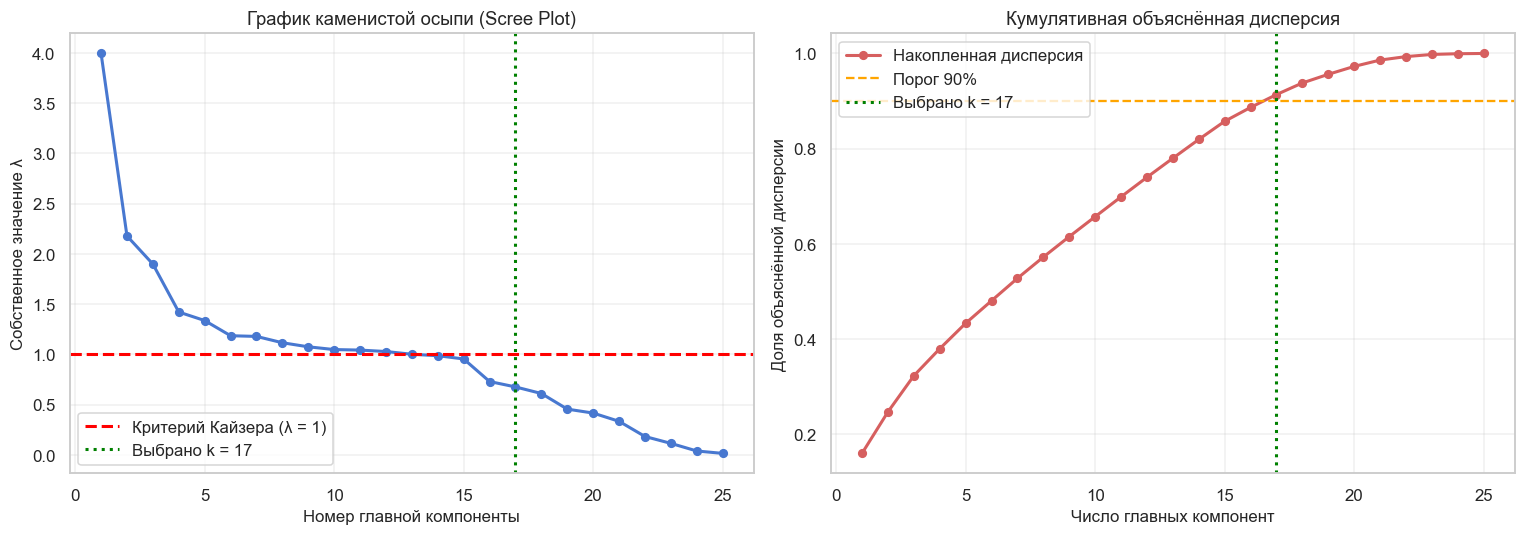

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-', lw=2, markersize=5)
axes[0].axhline(1.0, color='red', ls='--', lw=2, label='Критерий Кайзера (λ = 1)')
axes[0].axvline(k_opt, color='green', ls=':', lw=2, label=f'Выбрано k = {k_opt}')
axes[0].set_title('График каменистой осыпи (Scree Plot)')
axes[0].set_xlabel('Номер главной компоненты')
axes[0].set_ylabel('Собственное значение λ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cum_var) + 1), cum_var, 'ro-', lw=2, markersize=5, label='Накопленная дисперсия')
axes[1].axhline(0.90, color='orange', ls='--', label='Порог 90%')
axes[1].axvline(k_opt, color='green', ls=':', lw=2, label=f'Выбрано k = {k_opt}')
axes[1].set_title('Кумулятивная объяснённая дисперсия')
axes[1].set_xlabel('Число главных компонент')
axes[1].set_ylabel('Доля объяснённой дисперсии')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Scree plot и кумулятивная кривая обосновывают выбор числа компонент `k`. После выбора PCA переобучается с `n_components=k`, и исходные признаки заменяются некоррелированными главными компонентами — это как раз способ снизить мультиколлинеарность и размерность.

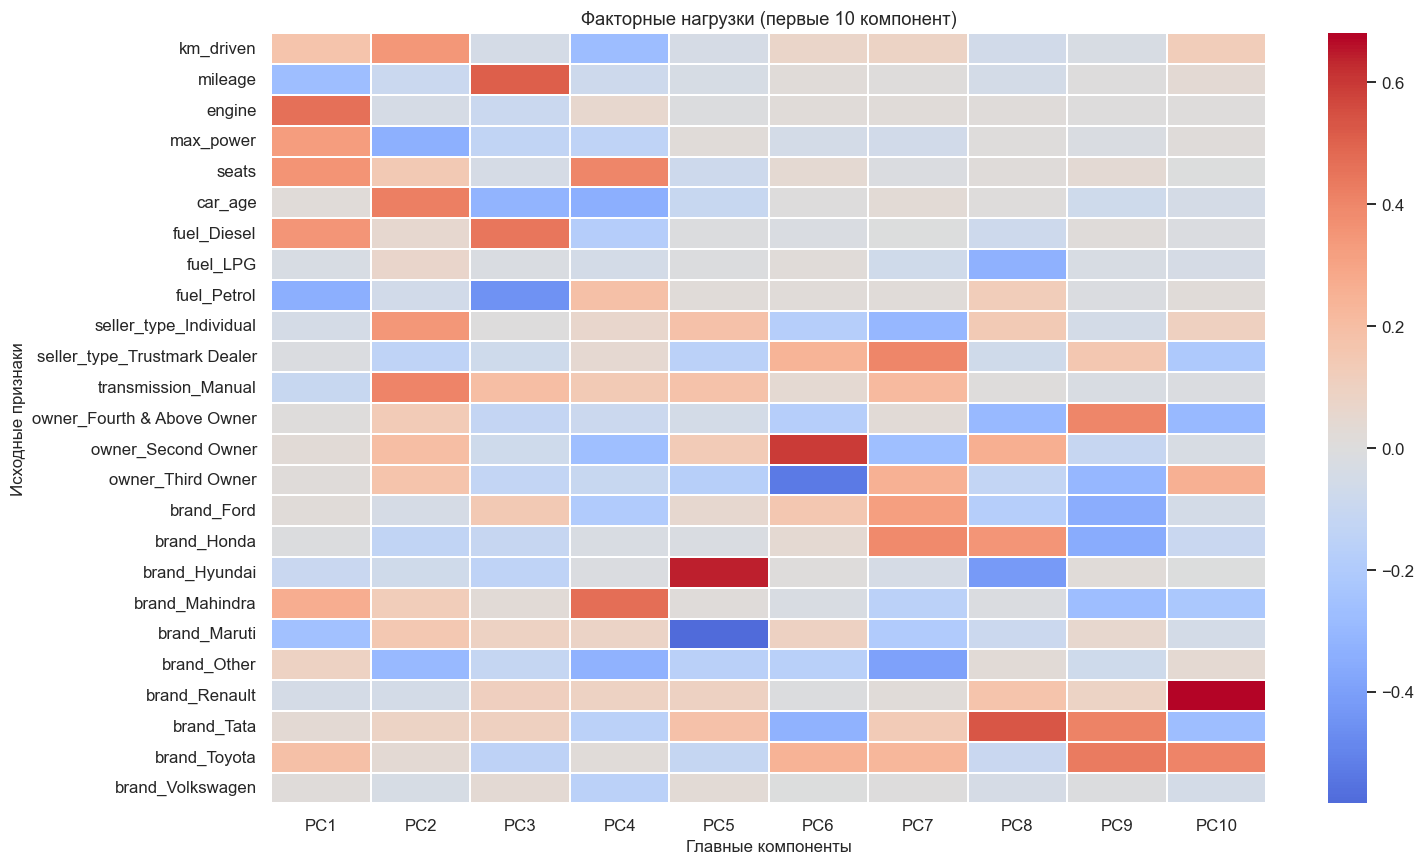

Размерность train до PCA:  (5354, 25)
Размерность train после PCA: (5354, 17)
Корреляции между первыми 5 PC на train (должны быть ≈ 0):


,PC1,PC2,PC3,PC4,PC5
PC1,1.0,0.0,0.0,-0.0,-0.0
PC2,0.0,1.0,0.0,-0.0,0.0
PC3,0.0,0.0,1.0,-0.0,-0.0
PC4,-0.0,-0.0,-0.0,1.0,0.0
PC5,-0.0,0.0,-0.0,0.0,1.0


In [17]:
pca = PCA(n_components=k_opt, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pc_names = [f'PC{i+1}' for i in range(k_opt)]

loadings = pd.DataFrame(pca.components_.T, index=feature_names, columns=pc_names)

plt.figure(figsize=(min(14, 1.1 * k_opt + 4), 8))
sns.heatmap(loadings.iloc[:, :min(10, k_opt)], annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title(f'Факторные нагрузки (первые {min(10, k_opt)} компонент)')
plt.ylabel('Исходные признаки')
plt.xlabel('Главные компоненты')
plt.tight_layout()
plt.show()

print(f'Размерность train до PCA:  {X_train_scaled.shape}')
print(f'Размерность train после PCA: {X_train_pca.shape}')
print('Корреляции между первыми 5 PC на train (должны быть ≈ 0):')
display(pd.DataFrame(X_train_pca[:, :min(5, k_opt)], columns=pc_names[:min(5, k_opt)]).corr().round(4))

Тепловая карта нагрузок показывает, какие исходные признаки сильнее всего входят в каждую компоненту. Корреляции между самими PC близки к нулю — мультиколлинеарность в пространстве компонент устранена по построению метода.

### 4.3. Регрессионные модели на главных компонентах

In [18]:
models_pca = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=10.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=100.0, random_state=RANDOM_STATE, max_iter=10000)
}

results_pca, fitted_pca, preds_pca = evaluate_models(
    models_pca, X_train_pca, X_test_pca, y_train, y_test,
    space_name=f'Главные компоненты ({k_opt})'
)

display(results_pca.round(4))

=== Модели: Главные компоненты (17) ===
Linear                       | R²(CV)=0.6116±0.0653 | R²(Test)=0.6430 | RMSE=284,761 | MAPE=51.98%
Ridge                        | R²(CV)=0.6116±0.0651 | R²(Test)=0.6430 | RMSE=284,749 | MAPE=51.93%
Lasso                        | R²(CV)=0.6116±0.0653 | R²(Test)=0.6430 | RMSE=284,758 | MAPE=51.95%


,Модель,Пространство,R² (CV mean),R² (CV std),R² (Test),RMSE (Test),"MAPE (Test), %"
0,Linear,Главные компоненты (17),0.6116,0.0653,0.643,284760.8335,51.9799
1,Ridge,Главные компоненты (17),0.6116,0.0651,0.643,284748.6853,51.9274
2,Lasso,Главные компоненты (17),0.6116,0.0653,0.643,284757.8843,51.9508


На главных компонентах те же три алгоритма обучаются заново. Если исходные признаки были сильно коррелированы, метрики после PCA могут стать стабильнее; если же отброшено слишком много информативной дисперсии, качество может немного упасть. Сравнение «до/после» — ключевой результат работы.

### 4.4. Сравнение метрик до и после PCA

Итоговая сравнительная таблица:


,Модель,Пространство,R² (CV mean),R² (CV std),R² (Test),RMSE (Test),"MAPE (Test), %"
0,Linear,Исходные признаки (25),0.6512,0.0629,0.6893,265651.1567,55.0750
1,Ridge,Исходные признаки (25),0.6513,0.0628,0.6893,265655.6308,54.9899
2,Lasso,Исходные признаки (25),0.6513,0.0628,0.6892,265678.1534,55.0548
3,Ridge,Главные компоненты (17),0.6116,0.0651,0.6430,284748.6853,51.9274
4,Lasso,Главные компоненты (17),0.6116,0.0653,0.6430,284757.8843,51.9508
5,Linear,Главные компоненты (17),0.6116,0.0653,0.6430,284760.8335,51.9799


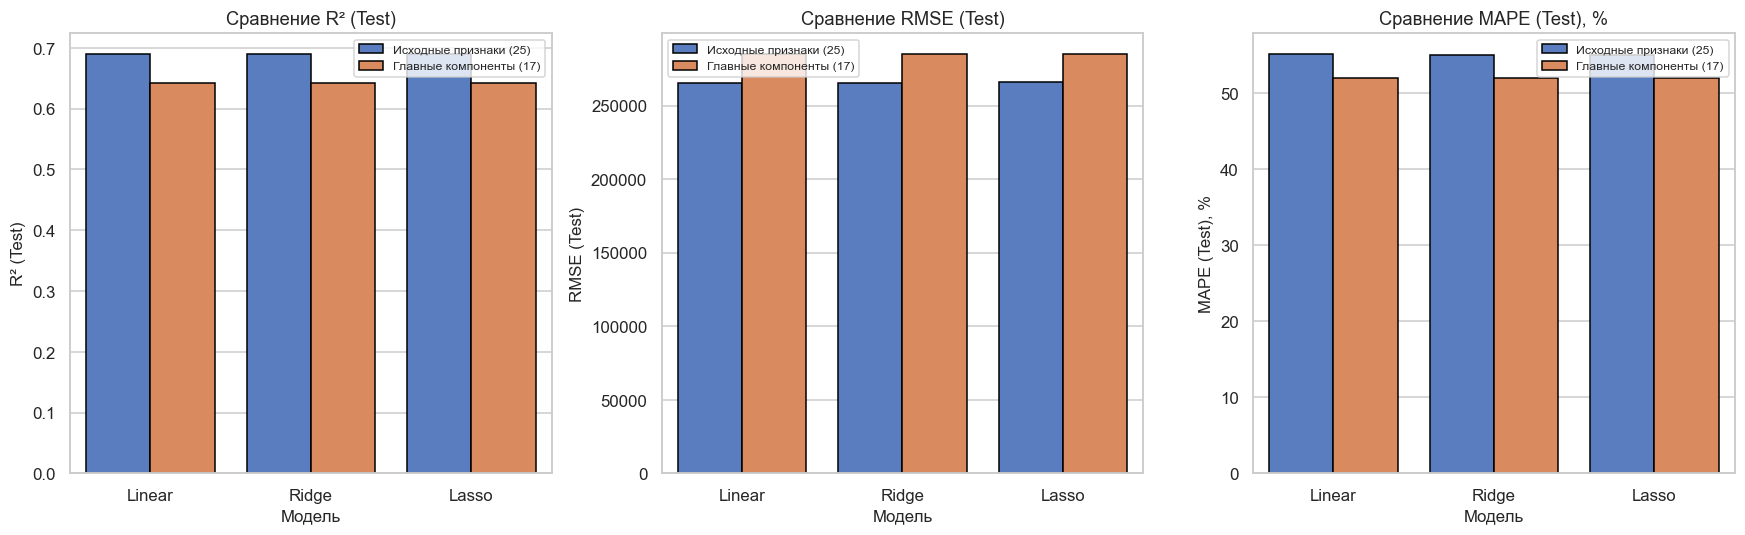


Лучшая модель по R² на тесте:
  Linear | Исходные признаки (25)
  R²=0.6893, RMSE=265,651, MAPE=55.08%


In [19]:
summary = pd.concat([results_orig, results_pca], ignore_index=True)
summary_sorted = summary.sort_values('R² (Test)', ascending=False).reset_index(drop=True)

print('Итоговая сравнительная таблица:')
display(summary_sorted.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
summary['Метка'] = summary['Модель'] + '\n' + summary['Пространство'].str.replace('Исходные признаки', 'Orig').str.replace('Главные компоненты', 'PCA')

sns.barplot(data=summary, x='Модель', y='R² (Test)', hue='Пространство', ax=axes[0], edgecolor='black')
axes[0].set_title('Сравнение R² (Test)')
axes[0].legend(fontsize=8)

sns.barplot(data=summary, x='Модель', y='RMSE (Test)', hue='Пространство', ax=axes[1], edgecolor='black')
axes[1].set_title('Сравнение RMSE (Test)')
axes[1].legend(fontsize=8)

sns.barplot(data=summary, x='Модель', y='MAPE (Test), %', hue='Пространство', ax=axes[2], edgecolor='black')
axes[2].set_title('Сравнение MAPE (Test), %')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

best = summary_sorted.iloc[0]
print('\nЛучшая модель по R² на тесте:')
print(f"  {best['Модель']} | {best['Пространство']}")
print(f"  R²={best['R² (Test)']:.4f}, RMSE={best['RMSE (Test)']:,.0f}, MAPE={best['MAPE (Test), %']:.2f}%")

**Как интерпретировать сравнение:**
- Если после PCA R² почти не упал (или вырос), а RMSE/MAPE не ухудшились — сжатие признакового пространства удалось без большой потери информации.
- Если качество заметно просело, значит отброшенные компоненты содержали полезный сигнал; тогда стоит увеличить `k` или оставить регуляризованные модели на исходных признаках.
- Ridge/Lasso на исходных данных часто конкурируют с PCA+Linear: оба подхода борются с мультиколлинеарностью разными механизмами.

## 5. Заключение

В работе на датасете цен автомобилей CarDekho выполнены все этапы пайплайна: загрузка и EDA, очистка и кодирование, диагностика мультиколлинеарности (корреляции + VIF), обучение Linear/Ridge/Lasso, снижение размерности PCA и повторное моделирование.

**Основные выводы:**
1. Цена продажи связана с мощностью, объёмом двигателя, возрастом автомобиля, типом трансмиссии и другими характеристиками — линейные модели улавливают существенную часть этой зависимости.
2. Между техническими признаками присутствует мультиколлинеарность (высокие корреляции и повышенный VIF), что делает оценки коэффициентов OLS менее устойчивыми.
3. Ridge и Lasso стабилизируют решение за счёт регуляризации; Lasso дополнительно выполняет отбор признаков.
4. PCA после стандартизации устраняет корреляции между предикторами и уменьшает число признаков; итоговые метрики позволяют выбрать компромисс между сжатием пространства и точностью прогноза.
5. Возможные пути улучшения: подбор гиперпараметров `alpha` через GridSearchCV, логарифмирование целевой переменной из-за асимметрии цены, нелинейные модели (деревья/градиентный бустинг) при сохранении интерпретируемого baseline на линейных моделях.

Практический результат лабораторной работы — воспроизводимое сравнение качества регрессии **до и после** факторного сжатия признаков.

Полный программный код вынесен в отдельные файлы `laba1_analysis.py` (загрузка, EDA, корреляции, VIF) и `laba1_models.py` (регрессия, PCA, сравнение метрик), по аналогии с примерами лабораторных работ.


## 6. Список источников

1. Dataset: Sukhmandeep Singh Brar. *Car Price Prediction Dataset*. Kaggle.  
   https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset
2. Pedregosa et al. *Scikit-learn: Machine Learning in Python*. JMLR, 2011.  
   https://scikit-learn.org/stable/
3. James G., Witten D., Hastie T., Tibshirani R. *An Introduction to Statistical Learning*. Springer.
4. Документация pandas: https://pandas.pydata.org/docs/
5. Документация statsmodels (VIF): https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html
6. Jolliffe I.T. *Principal Component Analysis*. Springer.